In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras import Model, Sequential
from time import time
from collections import Counter

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [12, 7]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 111
seed(seed_value)
set_seed(seed_value)

In [9]:
print("TensorFlow version:", tf.__version__)
print("Available devices:")
print(tf.config.list_physical_devices())

TensorFlow version: 2.16.2
Available devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
import pickle
import os

def load_cifar10_batch(batch_filename):
    with open(batch_filename, 'rb') as f:
        dict = pickle.load(f, encoding='bytes')
        data = dict[b'data']
        labels = dict[b'labels']
        data = data.reshape(len(data), 3, 32, 32).transpose(0, 2, 3, 1)
        return data, np.array(labels)

def load_cifar10_data(data_dir):
    x_train = []
    y_train = []
    # Завантаження 5 training batch'ів
    for i in range(1, 6):
        file = os.path.join(data_dir, f"data_batch_{i}")
        data, labels = load_cifar10_batch(file)
        x_train.append(data)
        y_train.append(labels)
    x_train = np.concatenate(x_train)
    y_train = np.concatenate(y_train)

    # Завантаження тестового набору
    x_test, y_test = load_cifar10_batch(os.path.join(data_dir, "test_batch"))
    return x_train, y_train, x_test, y_test

# Використання
data_dir = './data'
x_train, y_train, x_test, y_test = load_cifar10_data(data_dir)



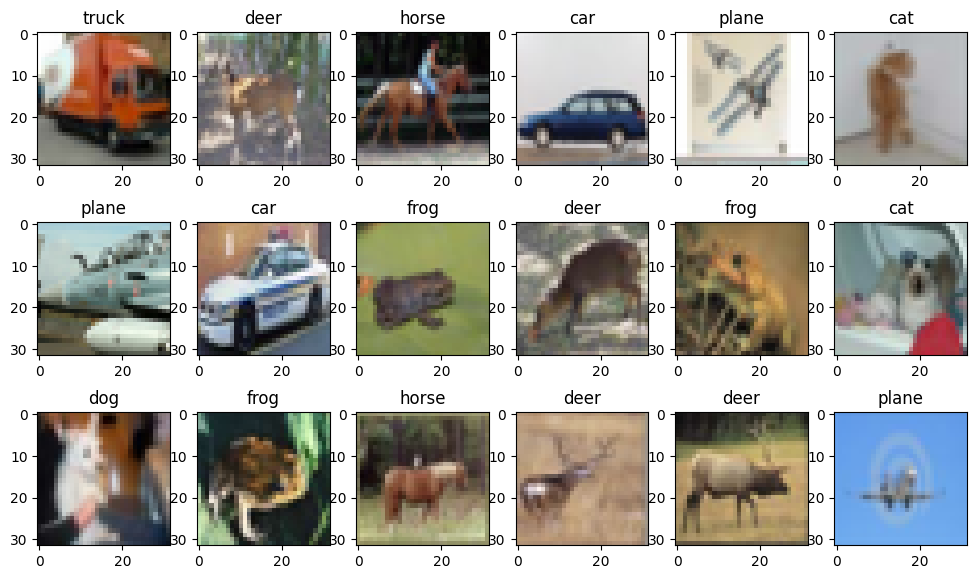

In [11]:
# Mapping from class ID to class name
classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

# Dataset params
num_classes = len(classes)
size = x_train.shape[1]

# Visualize random samples (as a plot with 3x6 samples)
for ii in range(18):    
    plt.subplot(3,6,ii+1)
    # Pick a random sample
    idx = np.random.randint(0, len(x_train))
    # Show the image and the label
    plt.imshow(x_train[idx, ...])
    plt.title(classes[int(y_train[idx])])

In [12]:
# Normalization
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding for labels
num_classes = len(classes)
y_train = tf.one_hot(y_train.flatten(), depth=num_classes)
y_test = tf.one_hot(y_test.flatten(), depth=num_classes)

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

input_shape = (size, size, 3)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

input_shape = (size, size, 3)  # наприклад, (32, 32, 3)

model = Sequential([
    Flatten(input_shape=input_shape),     
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.summary()

/Users/borovikdmitry/Repos/ML_CHI_IT_course/Lab_7/GPU_venv_py310/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,250 (1.53 MB)

 Trainable params: 402,250 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training
epochs = 25
batch_size = 32

start = time()
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
print('Elapsed time:', time() - start)

Epoch 1/25


2025-05-20 12:14:55.450987: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.1052 - loss: 17.9818 - val_accuracy: 0.1140 - val_loss: 2.4796
Epoch 2/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.1163 - loss: 2.5531 - val_accuracy: 0.1800 - val_loss: 2.2870
Epoch 3/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.1391 - loss: 2.4781 - val_accuracy: 0.1744 - val_loss: 2.3336
Epoch 4/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.1468 - loss: 2.4788 - val_accuracy: 0.1744 - val_loss: 2.2302
Epoch 5/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.1545 - loss: 2.4761 - val_accuracy: 0.1784 - val_loss: 2.2024
Epoch 6/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.1678 - loss: 2.4659 - val_accuracy: 0.2070 - val_loss: 2.2602
Epoch 7/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.1713 - loss: 2.4900 - val_accuracy: 0.1666 - val_loss: 2.4010
Epoch 8/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.1737 - loss: 2.5

Train Acc      0.18737778067588806
Validation Acc 0.19259999692440033


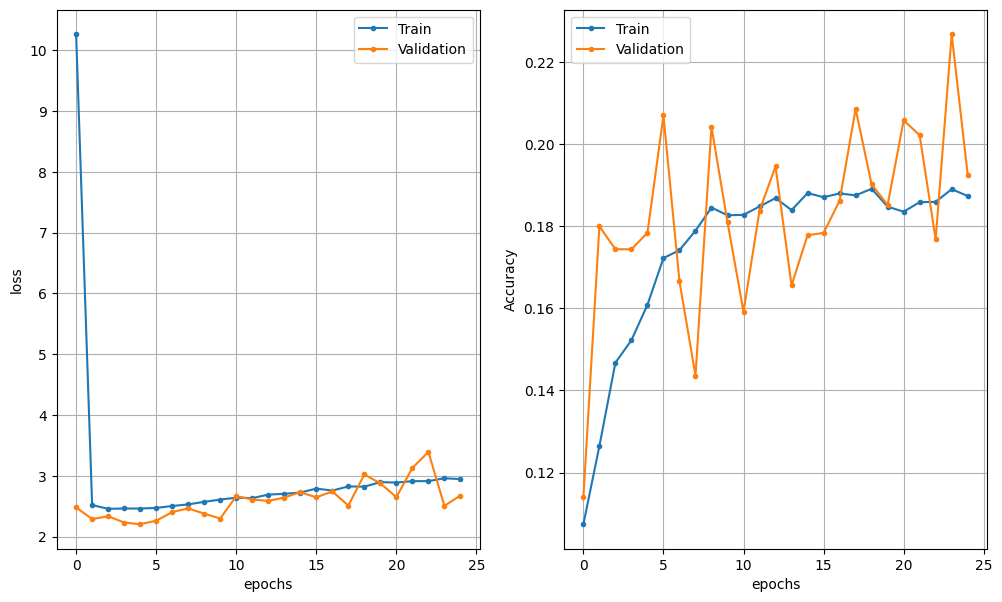

In [15]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])    

In [16]:
# Build the classifier
model = Sequential()

# 1 convolutional layer
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape = input_shape))
model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Dropout(0.25))

# 2 convolutional layer
model.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Dropout(0.45))

# 3 convolutional layer
model.add(Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(256, kernel_size=(3, 3),padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# 4 convolutional layer
model.add(Conv2D(16, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Dropout(0.6))

# Flatten layer
model.add(Flatten())

# First fully connected layer
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.75))

# Output layer with 10 neurons
model.add(Dense(10, activation='softmax'))

# Show the model
model.summary()

/Users/borovikdmitry/Repos/ML_CHI_IT_course/Lab_7/GPU_venv_py310/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 16)       │        36,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 7, 7, 16)       │            64 │
│ (BatchNormalization)            │                        │             

 Total params: 1,935,770 (7.38 MB)

 Trainable params: 1,933,434 (7.38 MB)

 Non-trainable params: 2,336 (9.12 KB)

In [17]:
# Compile the model
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# Training
epochs = 20
batch_size = 32

start = time()
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
print('Elapsed time:', time() - start)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - accuracy: 0.2343 - loss: 3.0266 - val_accuracy: 0.4030 - val_loss: 1.6732
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 44ms/step - accuracy: 0.4605 - loss: 1.4694 - val_accuracy: 0.5962 - val_loss: 1.1649
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - accuracy: 0.5840 - loss: 1.1897 - val_accuracy: 0.4948 - val_loss: 1.5911
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 60s 43ms/step - accuracy: 0.6418 - loss: 1.0471 - val_accuracy: 0.7200 - val_loss: 0.8279
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 60s 42ms/step - accuracy: 0.6927 - loss: 0.9188 - val_accuracy: 0.7532 - val_loss: 0.7418
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 59s 42ms/step - accuracy: 0.7273 - loss: 0.8214 - val_accuracy: 0.7804 - val_loss: 0.6620
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.7558 - loss: 0.7416 - val_accuracy: 0.7514 - val_loss: 0.8091
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 309s 220ms/step - accuracy: 0.7797

Train Acc      0.8994888663291931
Validation Acc 0.84579998254776


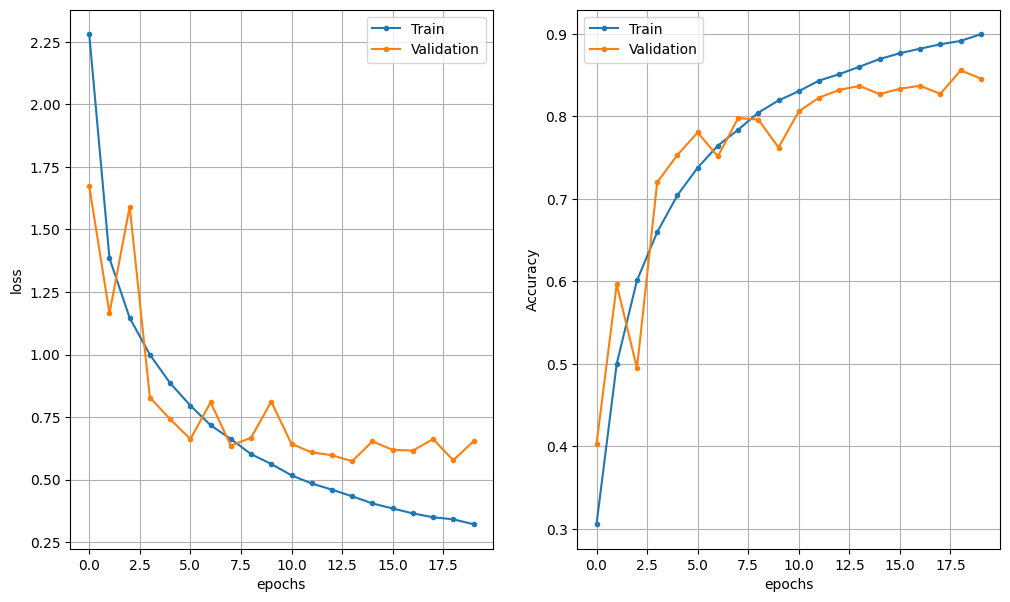

In [18]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])    

In [19]:
# Compute the labels and the predictions as sparse values
y_true = tf.argmax(y_test, axis=1).numpy().flatten()
y_pred = np.argmax(model.predict(x_test), axis=-1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [20]:
# Compute and print the accuracy for each class
for class_id, class_name in classes.items():
    class_indices = np.where(y_true == class_id)[0]
    class_correct = np.sum(y_true[class_indices] == y_pred[class_indices])
    acc = class_correct / len(class_indices) if len(class_indices) > 0 else 0
    print(f"{class_name}: {acc:.2f}")

plane: 0.81
car: 0.90
bird: 0.71
cat: 0.59
deer: 0.84
dog: 0.75
frog: 0.95
horse: 0.87
ship: 0.92
truck: 0.92


In [21]:
# Print the overall stats
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8270 - loss: 0.7171
Test loss   0.7089343667030334
Test metric 0.8266000151634216


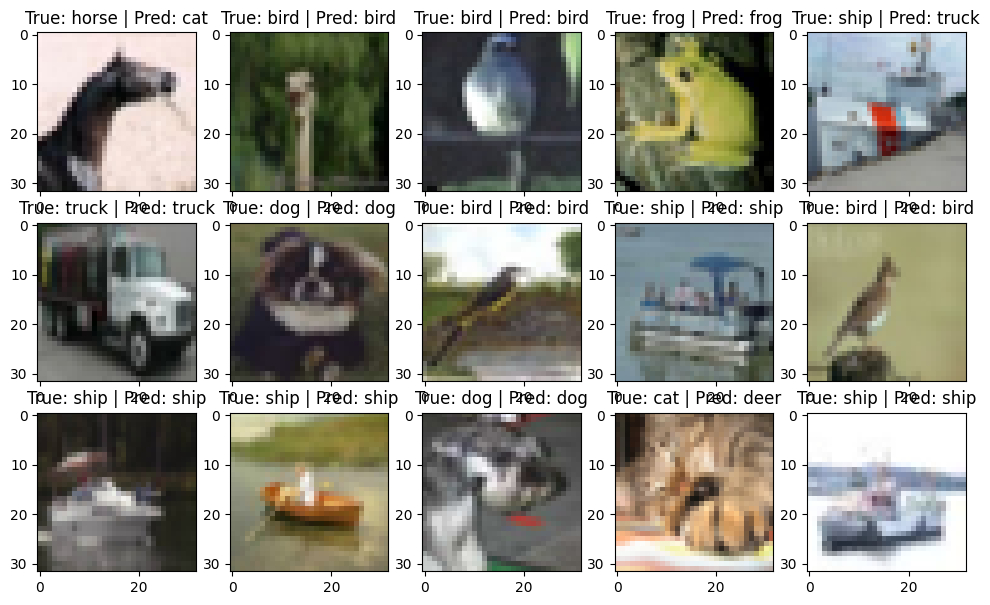

In [22]:
# Show random samples
for ii in range(15):
    # Pick a random sample
    idx = np.random.randint(0, len(x_test) - 1)
    # Show the results
    plt.subplot(3,5,ii+1), plt.imshow(x_test[idx, ...])
    plt.title('True: ' + str(classes[y_true[idx]]) + ' | Pred: ' + str(classes[y_pred[idx]]))

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import os

# Training
epochs = 15
batch_size = 32

# Директорія для зберігання логів
log_dir = os.path.join("logs", "fit", "model")

# Налаштування колбеків
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
tensorboard = TensorBoard(log_dir=log_dir, histogram_freq=1)

start = time()
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test),
                    callbacks=[early_stopping, tensorboard])


print('Elapsed time:', time() - start)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.8823 - loss: 0.3794 - val_accuracy: 0.8412 - val_loss: 0.5644
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.8898 - loss: 0.3552 - val_accuracy: 0.8309 - val_loss: 0.6145
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.8945 - loss: 0.3378 - val_accuracy: 0.8427 - val_loss: 0.5844
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.8977 - loss: 0.3225 - val_accuracy: 0.8528 - val_loss: 0.5568
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.9071 - loss: 0.2909 - val_accuracy: 0.8428 - val_loss: 0.6373
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.9127 - loss: 0.2836 - val_accuracy: 0.8547 - val_loss: 0.5996
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.9131 - loss: 0.2785 - val_accuracy: 0.8557 - val_loss: 0.5898
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.9179 -

Train Acc      0.9196400046348572
Validation Acc 0.8447999954223633


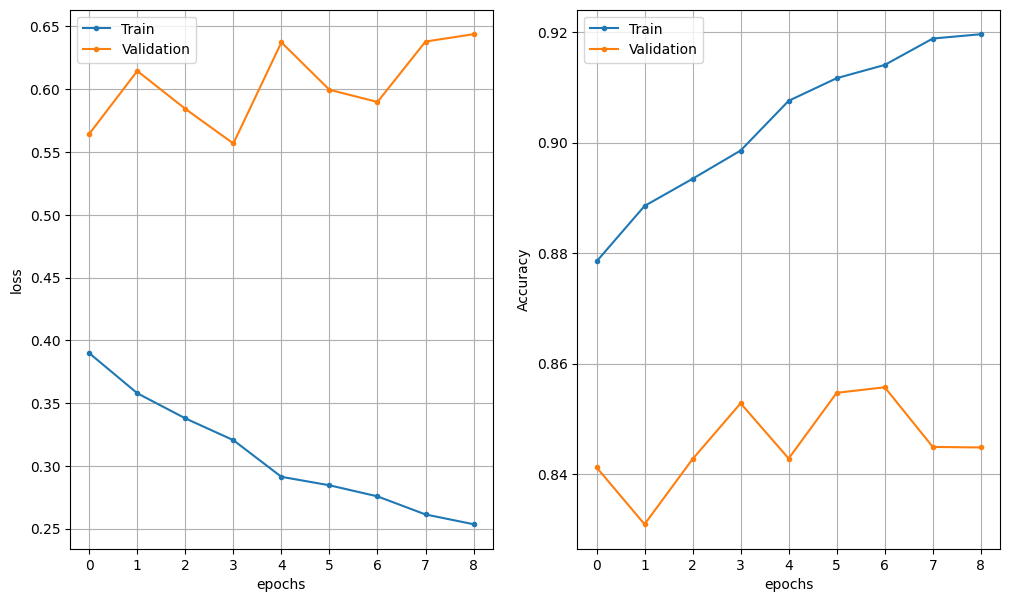

In [24]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])    

In [25]:
# Compute the labels and the predictions as sparse values
y_true = tf.argmax(y_test, axis=1).numpy().flatten()
y_pred = np.argmax(model.predict(x_test), axis=-1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [26]:
# Compute and print the accuracy for each class
for class_id, class_name in classes.items():
    class_indices = np.where(y_true == class_id)[0]
    class_correct = np.sum(y_true[class_indices] == y_pred[class_indices])
    acc = class_correct / len(class_indices) if len(class_indices) > 0 else 0
    print(f"{class_name}: {acc:.2f}")

plane: 0.91
car: 0.93
bird: 0.71
cat: 0.73
deer: 0.83
dog: 0.77
frog: 0.89
horse: 0.92
ship: 0.91
truck: 0.92


In [27]:
# Print the overall stats
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8510 - loss: 0.5583
Test loss   0.556775689125061
Test metric 0.8528000116348267


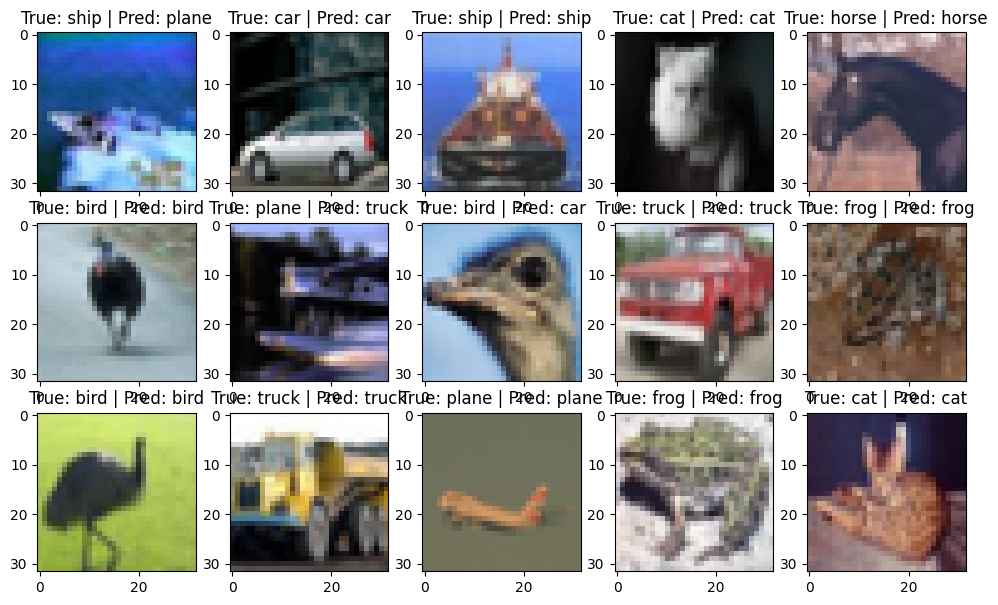

In [28]:
# Show random samples
for ii in range(15):
    # Pick a random sample
    idx = np.random.randint(0, len(x_test) - 1)
    # Show the results
    plt.subplot(3,5,ii+1), plt.imshow(x_test[idx, ...])
    plt.title('True: ' + str(classes[y_true[idx]]) + ' | Pred: ' + str(classes[y_pred[idx]]))